<a href="https://colab.research.google.com/github/Anggirahdillah/nlp-student-answer-analysis/blob/main/NLP_Based_Analysis_of_Student_Answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP-Based Analysis of Student Answers

This project analyzes student answers using basic Natural Language Processing techniques.

The analysis includes:
- Answer correctness analysis
- Spelling error detection
- Levenshtein distance
- Spelling error classification
- Word segmentation analysis
- Data visualization

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving jawaban_siswa.xlsx to jawaban_siswa.xlsx


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('jawaban_siswa.xlsx')

In [ ]:
print(df.columns.tolist())

['ID', 'Siswa', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S28A', 'S28B', 'S29A', 'S29B', 'S30A', 'S30B']


In [ ]:
print(df.shape)

(18, 19)


In [ ]:
df.head()


,ID,Siswa,S16,S17,S18,S19,S20,S21,S22,S23,S24,S25,S26,S28A,S28B,S29A,S29B,S30A,S30B
0,1,S1,Keinginan,Pukis,Angklung,Ne,Kertas,Dokter,Berdo'a,Mobil pemadam kebakaran,Polisi,Nahkoda,"Buku tulis, Gantungan HP",Ten-ta-ra,Ma-si-nis,Dokter,Koki,Atas,Samping
1,2,S2,Keinginan,Kuwe Pukis,Angklung,Ne,Kertas,Dokter,Baca Doa,Pemadam Kebakaran,Polisi,Nahkoda,"Ipad, Hp",Ten-ta-ra,Ma-si-nis,Dokter,Koki,Atas,Samping
2,3,S3,Keinginan,Pukis,Angklung,Ne,Kertas,Dokter,Baca Doa,Damkar,Polisi,Narkoda,"Baju, Bando",Ten-tara,Masi-nis,Dokter,Koki,Atas,Samping
3,4,S4,Keinginan,Pukis,Angkung,Ne,Kertas,Dokter,Doa,Pemadam Kebakaran,Polisi,Pemendara kapal,"Mofusand, Baju",Mejagaalam,mendarai kereta,Dokter,Koki,Atas,Samping
4,5,S5,Keinginan,Pukis,Angklung,Ne,Kertas,Dokter,Doa,Pemidam Kebakaran,Polisi,Masinis,"Tas baru, Tempat pensil",Ten-ta-ra,Ma-si-nis,Dokter,Koki,Atas,Samping


In [ ]:
df_raw = df.copy()

In [ ]:
for col in df.columns[2:]:
    df[col] = df[col].str.lower()

In [ ]:
df.head()

,ID,Siswa,S16,S17,S18,S19,S20,S21,S22,S23,S24,S25,S26,S28A,S28B,S29A,S29B,S30A,S30B
0,1,S1,keinginan,pukis,angklung,ne,kertas,dokter,berdo'a,mobil pemadam kebakaran,polisi,nahkoda,"buku tulis, gantungan hp",ten-ta-ra,ma-si-nis,dokter,koki,atas,samping
1,2,S2,keinginan,kuwe pukis,angklung,ne,kertas,dokter,baca doa,pemadam kebakaran,polisi,nahkoda,"ipad, hp",ten-ta-ra,ma-si-nis,dokter,koki,atas,samping
2,3,S3,keinginan,pukis,angklung,ne,kertas,dokter,baca doa,damkar,polisi,narkoda,"baju, bando",ten-tara,masi-nis,dokter,koki,atas,samping
3,4,S4,keinginan,pukis,angkung,ne,kertas,dokter,doa,pemadam kebakaran,polisi,pemendara kapal,"mofusand, baju",mejagaalam,mendarai kereta,dokter,koki,atas,samping
4,5,S5,keinginan,pukis,angklung,ne,kertas,dokter,doa,pemidam kebakaran,polisi,masinis,"tas baru, tempat pensil",ten-ta-ra,ma-si-nis,dokter,koki,atas,samping


# ANALISIS JAWABAN BENAR DAN SALAH SISWA

In [ ]:
kunci_jawaban = {
    'S16':'keinginan',
    'S17':'pukis',
    'S18':'angklung',
    'S19':'ne',
    'S20':'kertas',
    'S21':'dokter',
    'S24':'polisi',
    'S25':'nahkoda',
    'S29A':'dokter',
    'S29B':'koki',
    'S30A':'atas',
    'S30B':'samping'
}

In [ ]:
hasil_nilai = []

for soal, kunci in kunci_jawaban.items():

    benar = (df[soal] == kunci).sum()
    salah = len(df) - benar

    hasil_nilai.append({
        'Soal': soal,
        'Benar': benar,
        'Salah': salah
    })

nilai_df = pd.DataFrame(hasil_nilai)

nilai_df

,Soal,Benar,Salah
0,S16,18,0
1,S17,12,6
2,S18,10,8
3,S19,18,0
4,S20,17,1
5,S21,15,3
6,S24,16,2
7,S25,9,9
8,S29A,16,2
9,S29B,17,1


In [ ]:
daftar_salah = []

for soal, kunci in kunci_jawaban.items():

    for _, row in df.iterrows():

        if row[soal] != kunci:

            daftar_salah.append({
                'Siswa': row['Siswa'],
                'Soal': soal,
                'Jawaban_Siswa': row[soal],
                'Jawaban_Benar': kunci
            })

salah_df = pd.DataFrame(daftar_salah)

salah_df.head(20)

,Siswa,Soal,Jawaban_Siswa,Jawaban_Benar
0,S2,S17,kuwe pukis,pukis
1,S9,S17,kue cubit,pukis
2,S10,S17,peki,pukis
3,S13,S17,cucur,pukis
4,S15,S17,cubit,pukis
5,S16,S17,puputu,pukis
6,S4,S18,angkung,angklung
7,S6,S18,angklune,angklung
8,S8,S18,alat musik angklung,angklung
9,S9,S18,1000 logam,angklung


In [ ]:
print("Jumlah jawaban tidak sesuai:", len(salah_df))

Jumlah jawaban tidak sesuai: 33


# ANALISIS KESALAHAN EJAAN

In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.8 MB/s eta 0:00:00


In [ ]:
from Levenshtein import distance

In [ ]:
hasil = []

for soal, kunci in kunci_jawaban.items():

    for _, row in df.iterrows():

        jawaban = str(row[soal]).strip()

        if jawaban != kunci:

            jarak = distance(jawaban, kunci)

            if jarak <= 2:

                hasil.append({
                    'Siswa': row['Siswa'],
                    'Soal': soal,
                    'Jawaban_Siswa': jawaban,
                    'Jawaban_Benar': kunci,
                    'Levenshtein': jarak
                })

ejaan_df = pd.DataFrame(hasil)

ejaan_df

,Siswa,Soal,Jawaban_Siswa,Jawaban_Benar,Levenshtein
0,S10,S17,peki,pukis,2
1,S4,S18,angkung,angklung,1
2,S6,S18,angklune,angklung,1
3,S15,S18,angkelung,angklung,1
4,S16,S18,angklong,angklung,1
5,S10,S20,ketas,kertas,1
6,S10,S21,doter,dokter,1
7,S15,S21,doter,dokter,1
8,S16,S21,bokter,dokter,1
9,S10,S24,pilisis,polisi,2


## Klasifikasi Kesalahan Ejaan

In [ ]:
def jenis_ejaan(salah, benar):

    if len(salah) < len(benar):
        return 'Penghilangan Huruf'

    elif len(salah) > len(benar):
        return 'Penambahan Huruf'

    else:
        return 'Penggantian Huruf'

In [ ]:
ejaan_df['Jenis_Kesalahan'] = ejaan_df.apply(
    lambda x: jenis_ejaan(
        x['Jawaban_Siswa'],
        x['Jawaban_Benar']
    ),
    axis=1
)

ejaan_df

,Siswa,Soal,Jawaban_Siswa,Jawaban_Benar,Levenshtein,Jenis_Kesalahan
0,S10,S17,peki,pukis,2,Penghilangan Huruf
1,S4,S18,angkung,angklung,1,Penghilangan Huruf
2,S6,S18,angklune,angklung,1,Penggantian Huruf
3,S15,S18,angkelung,angklung,1,Penambahan Huruf
4,S16,S18,angklong,angklung,1,Penggantian Huruf
5,S10,S20,ketas,kertas,1,Penghilangan Huruf
6,S10,S21,doter,dokter,1,Penghilangan Huruf
7,S15,S21,doter,dokter,1,Penghilangan Huruf
8,S16,S21,bokter,dokter,1,Penggantian Huruf
9,S10,S24,pilisis,polisi,2,Penambahan Huruf


## Rekapitulasi Jenis Kesalahan Ejaan

In [ ]:
ejaan_df['Jenis_Kesalahan'].value_counts()

,count
Jenis_Kesalahan,
Penggantian Huruf,7
Penghilangan Huruf,6
Penambahan Huruf,2


## Rekapitulasi Kesalahan Ejaan Berdasarkan Soal

In [ ]:
ejaan_df['Soal'].value_counts()

,count
Soal,
S18,4
S21,3
S29A,2
S25,2
S20,1
S17,1
S24,1
S30B,1


## Visualisasi Kesalahan Ejaan

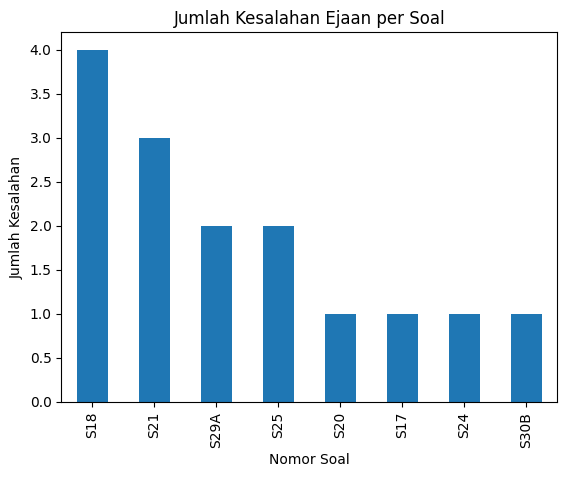

In [ ]:
ejaan_df['Soal'].value_counts().plot(kind='bar')

plt.title('Jumlah Kesalahan Ejaan per Soal')
plt.xlabel('Nomor Soal')
plt.ylabel('Jumlah Kesalahan')

plt.show()

# ANALISIS PEMENGGALAN KATA

In [ ]:
salah_28a = df[
    df['S28A'] != 'ten-ta-ra'
][['Siswa','S28A']]

salah_28a

,Siswa,S28A
2,S3,ten-tara
3,S4,mejagaalam
8,S9,ten-tara
11,S12,te-nt-ara
12,S13,te-n-ta-ra
15,S16,ten-tara


In [ ]:
salah_28b = df[
    df['S28B'] != 'ma-si-nis'
][['Siswa','S28B']]

salah_28b

,Siswa,S28B
2,S3,masi-nis
3,S4,mendarai kereta
8,S9,masi-nis
11,S12,mas-inis
15,S16,masi-nis


In [ ]:
jumlah_28a = len(salah_28a)
jumlah_28b = len(salah_28b)

print("Kesalahan 28A:", jumlah_28a)
print("Kesalahan 28B:", jumlah_28b)
print("Total Kesalahan Pemenggalan:", jumlah_28a + jumlah_28b)

Kesalahan 28A: 6
Kesalahan 28B: 5
Total Kesalahan Pemenggalan: 11


In [ ]:
pemenggalan_df = pd.DataFrame({
    'Soal':['S28A','S28B'],
    'Jumlah_Kesalahan':[jumlah_28a,jumlah_28b]
})

pemenggalan_df

,Soal,Jumlah_Kesalahan
0,S28A,6
1,S28B,5


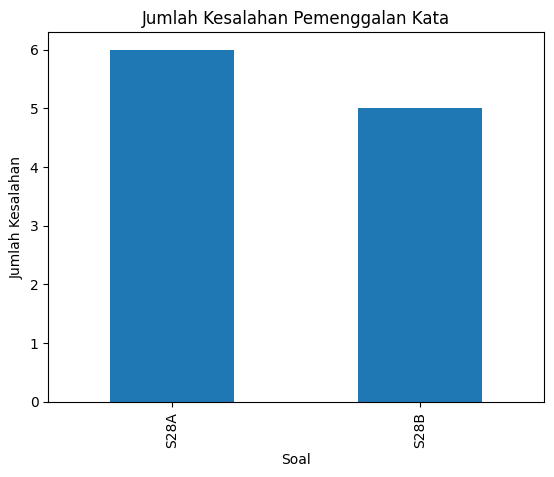

In [ ]:
pemenggalan_df.plot(
    x='Soal',
    y='Jumlah_Kesalahan',
    kind='bar',
    legend=False
)

plt.title('Jumlah Kesalahan Pemenggalan Kata')
plt.xlabel('Soal')
plt.ylabel('Jumlah Kesalahan')

plt.show()

# REKAPITULASI HASIL ANALISIS

In [ ]:
total_jawaban_salah = len(salah_df)
total_ejaan = len(ejaan_df)
total_pemenggalan = jumlah_28a + jumlah_28b

rekap_df = pd.DataFrame({
    'Jenis_Analisis': [
        'Jawaban Tidak Sesuai',
        'Kesalahan Ejaan',
        'Kesalahan Pemenggalan Kata'
    ],
    'Jumlah': [
        total_jawaban_salah,
        total_ejaan,
        total_pemenggalan
    ]
})

rekap_df

,Jenis_Analisis,Jumlah
0,Jawaban Tidak Sesuai,33
1,Kesalahan Ejaan,15
2,Kesalahan Pemenggalan Kata,11


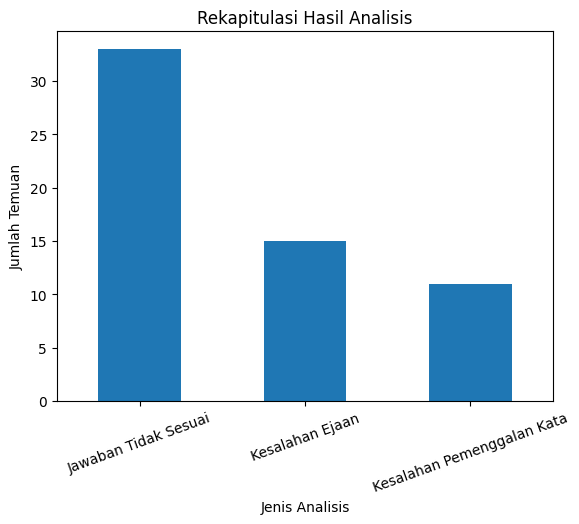

In [ ]:
rekap_df.plot(
    x='Jenis_Analisis',
    y='Jumlah',
    kind='bar',
    legend=False
)

plt.title('Rekapitulasi Hasil Analisis')
plt.xlabel('Jenis Analisis')
plt.ylabel('Jumlah Temuan')

plt.xticks(rotation=20)
plt.show()

# EXPORT HASIL

In [ ]:
ejaan_df.to_excel(
    'hasil_kesalahan_ejaan.xlsx',
    index=False
)

In [ ]:
pemenggalan_df.to_excel(
    'hasil_pemenggalan.xlsx',
    index=False
)

In [ ]:
rekap_df.to_excel(
    'hasil_rekap.xlsx',
    index=False
)

In [ ]:
from google.colab import files

files.download('hasil_kesalahan_ejaan.xlsx')
files.download('hasil_pemenggalan.xlsx')
files.download('hasil_rekap.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>